## **8.  변형 회귀 (Variant Regression)**
- 선형 회귀가 갖는 다양한 한계를 보완하기 위해 확장된 회귀 모델들

- 선형 회귀(OLS) 가정
    1. 선형성(linearity)
    2. 정규성(normality)
    3. 등분산성(homoscedasticity)
    4. 독립성(independence)

- 하지만 실제 데이터는 이러한 가정을 자주 위반 
- 변수 개수가 많거나 비선형 패턴 존재  
- 이를 해결하기 위해 여러 변형 회귀 기법(Variant Regression)을 사용

### **필요한 라이브러리 가져오기**

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, QuantileRegressor, BayesianRidge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

import statsmodels.api as sm
import statsmodels.formula.api as smf
from patsy import dmatrix

import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 11

### **데이터 불러오기**

In [2]:
df = pd.read_csv('../data/california_housing.csv')
print("\n데이터 셋의 일부를 확인해보면 아래와 같습니다.")
df.head()


데이터 셋의 일부를 확인해보면 아래와 같습니다.


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


<html>
<b><font size=4>* 변수에 대한 설명</font></b><br><br>

- MedInc : 지역의 중위소득 (Median Income)<br>
- HouseAge : 주택의 평균 연식 (Average House Age)<br>
- AveRooms : 가구당 평균 방(room) 수<br>
- AveBedrms : 가구당 평균 침실 수<br>
- Population : 지역 인구수<br>
- AveOccup : 가구당 평균 거주자 수<br>
- Latitude : 위도<br>
- Longitude : 경도<br>
- MedHouseVal : 지역의 중위 주택가격 (Target, 단위: 10만 달러)<br>
</html>

### **데이터 전처리**
- 데이터 결측치 확인

In [3]:
df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

- 데이터 중복 확인

In [4]:
df.duplicated().sum()

np.int64(0)

- describe() 함수를 사용해서 수치형 변수들만을 기준으로 카운트, 평균, 표준편차, 최소/최댓값, 4분위 수를 확인

In [5]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


### **데이터 시각화**
- 변수 간 상관 관계 파악

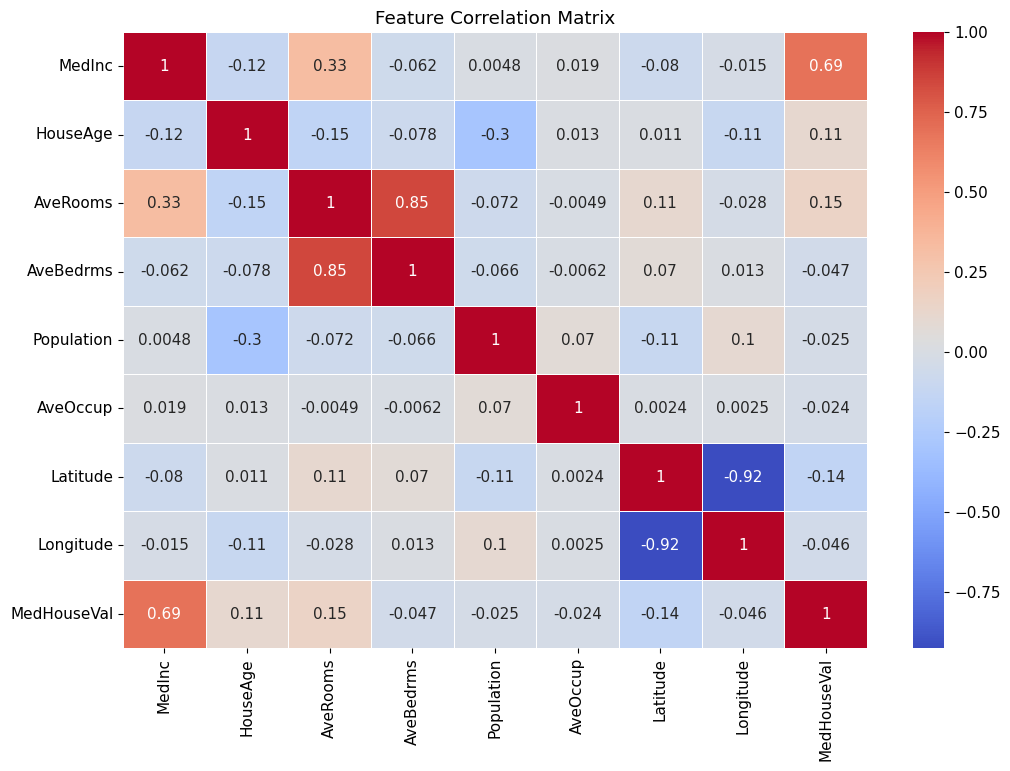

In [6]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.show()

- 각 특성의 분포에 대한 히스토그램

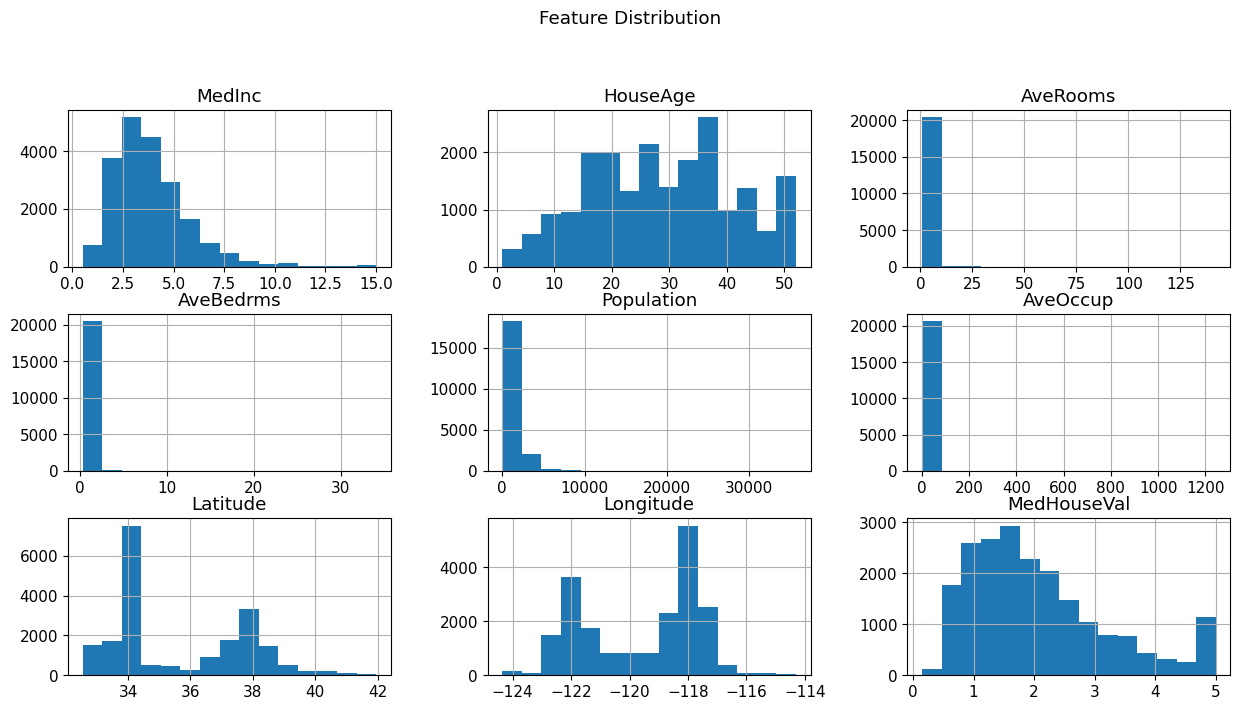

In [7]:
df.hist(bins=15, figsize=(15, 10), layout=(4, 3))
plt.suptitle('Feature Distribution')
plt.show()

### **데이터 분리**
- 데이터를 학습 데이터 세트와 테스트 데이터 세트로 분리

In [8]:
# 독립 변수(X)와 종속 변수(y)를 정의
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

- 데이터의 80%는 학습에 사용되고 20%는 테스트에 사용

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("\n학습 세트 크기:", X_train.shape[0])
print("테스트 세트 크기:", X_test.shape[0])


학습 세트 크기: 16512
테스트 세트 크기: 4128


- Feature Scaling

In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 스케일링 후 DataFrame으로 복원 (인덱스 유지)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X_test.columns, index=X_test.index)

### **Linear Regression**
- LinearRegression 모델 생성 및 학습

In [11]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


- 테스트 데이터에 대한 가격 예측

In [12]:
y_pred_lr = lr_model.predict(X_test_scaled)

print("\n모델 계수(기울기):", lr_model.coef_[0])
print("모델 절편(y절편):", lr_model.intercept_)


모델 계수(기울기): 0.8543830309268542
모델 절편(y절편): 2.0719469373788777


- MAE, MSE, R2 값을 비교하여 모델을 평가

In [13]:
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("\n[Linear Regression 모델 평가 지표]")
print("\n- 평균 절대 오차 (MAE):", round(mae_lr, 4))
print("- 평균 제곱 오차 (MSE):", round(mse_lr, 4))
print("- R-제곱 (R2) 값:", round(r2_lr, 4))


[Linear Regression 모델 평가 지표]

- 평균 절대 오차 (MAE): 0.5332
- 평균 제곱 오차 (MSE): 0.5559
- R-제곱 (R2) 값: 0.5758


### **8-1 Stepwise Regression**


- 불필요한 변수를 제거하고 중요한 변수만 선택하는 회귀 방식
- **Forward Selection**: 유의한 변수를 하나씩 추가  
- **Backward Elimination**: 덜 유의한 변수를 하나씩 제거  
- **Bidirectional**: 두 방법을 동시에 적용하여 균형 잡힌 선택 수행  
- 기준
  - p-value
  - AIC/BIC
- 장점:  
  - 많은 후보 변수 중 핵심 변수 자동 선택  
  - 모델 복잡도 감소  
- 단점:  
  - 탐욕적(greedy) → 전역 최적 보장 안 됨  
  - 다중공선성(multicollinearity)에 취약  
  - 변수 선택 과정에서 과적합 위험 존재

## **8-1-1. 전진선택법 (Forward Selection)**

- **Forward Selection**: 유의한 변수를 하나씩 추가  

In [14]:
import matplotlib.pyplot as plt

# 가정: forward_selection 함수에서 성능(metric)과 선택된 변수를 반환하도록 수정
def forward_selection_with_visualization(X, y, significance_level=0.05):
    initial_features = []
    remaining_features = list(X.columns)
    selected_features = []
    model_performance = []  # 모델 성능 추적 (예: R^2 또는 AIC)

    while remaining_features:
        best_pval = float("inf")
        best_feature = None
        for feature in remaining_features:
            X_subset = sm.add_constant(X[initial_features + [feature]])
            model = sm.OLS(y, X_subset).fit()
            pval = model.pvalues[feature]
            if pval < best_pval and pval < significance_level:
                best_pval = pval
                best_feature = feature
        if best_feature:
            initial_features.append(best_feature)
            remaining_features.remove(best_feature)
            selected_features.append(best_feature)
            # 모델 성능 저장
            X_subset = sm.add_constant(X[initial_features])
            model = sm.OLS(y, X_subset).fit()
            model_performance.append(model.rsquared)  # R^2 값 저장
        else:
            break
    return selected_features, model_performance

selected_features, model_performance = forward_selection_with_visualization(X, y)

print("전진 선택법 이후 선택된 변수들 :", selected_features)
print("전진 선택에 따른 모델 성능:", model_performance)


전진 선택법 이후 선택된 변수들 : ['MedInc', 'HouseAge', 'Latitude', 'Longitude', 'AveBedrms', 'AveRooms', 'AveOccup']
전진 선택에 따른 모델 성능: [np.float64(0.47344749180719903), np.float64(0.5091195899765226), np.float64(0.5171927045652198), np.float64(0.5940250548052656), np.float64(0.5988375576365015), np.float64(0.6050397785905599), np.float64(0.6062193051855561)]


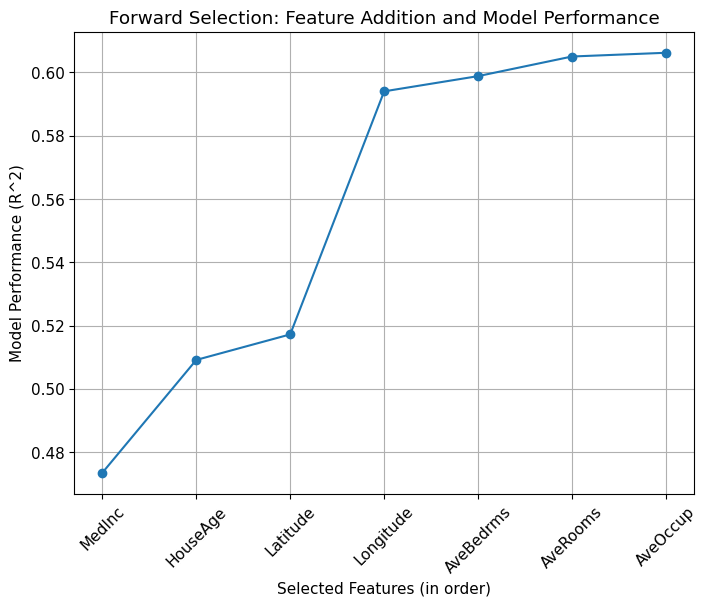

In [15]:
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(model_performance) + 1), model_performance, marker='o', linestyle='-')
plt.xticks(range(1, len(model_performance) + 1), selected_features, rotation=45)
plt.xlabel('Selected Features (in order)')
plt.ylabel('Model Performance (R^2)')
plt.title('Forward Selection: Feature Addition and Model Performance')
plt.grid()
plt.show()

## **8-1-2. 후진제거법 (Backward Elimination)**

- **Backward Elimination**: 덜 유의한 변수를 하나씩 제거  

In [16]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

# 후진 소거법 구현
def backward_elimination_with_visualization(X, y, significance_level=0.05):
    features = list(X.columns)  # 모든 독립 변수 포함
    model_performance = []  # 모델 성능 기록 (R^2)

    while len(features) > 0:
        # 현재 변수로 회귀 모델 생성
        #X_subset = sm.add_constant(X[features])  # 상수항 추가
        X_subset = X[features]
        model = sm.OLS(y, X_subset).fit()

        # R^2 기록
        model_performance.append(model.rsquared)

        # p-value가 가장 높은 변수 찾기
        pvalues = model.pvalues[1:]  # 상수(constant)는 제외
        max_pval = pvalues.max()

        if max_pval > significance_level:  # 유의수준 초과 시 변수 제거
            excluded_feature = pvalues.idxmax()
            features.remove(excluded_feature)
        else:
            break  # 모든 변수의 p-value가 유의수준 이하일 경우 종료

    return features, model_performance

selected_features_backward, model_performance_backward = backward_elimination_with_visualization(X, y)

print("후진 제거법 이후 선택된 변수들 :", selected_features_backward)
print("후진 제거에 따른 모델 성능:", model_performance_backward)


후진 제거법 이후 선택된 변수들 : ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup', 'Latitude', 'Longitude']
후진 제거에 따른 모델 성능: [np.float64(0.8923070471015435), np.float64(0.8922948286170415)]


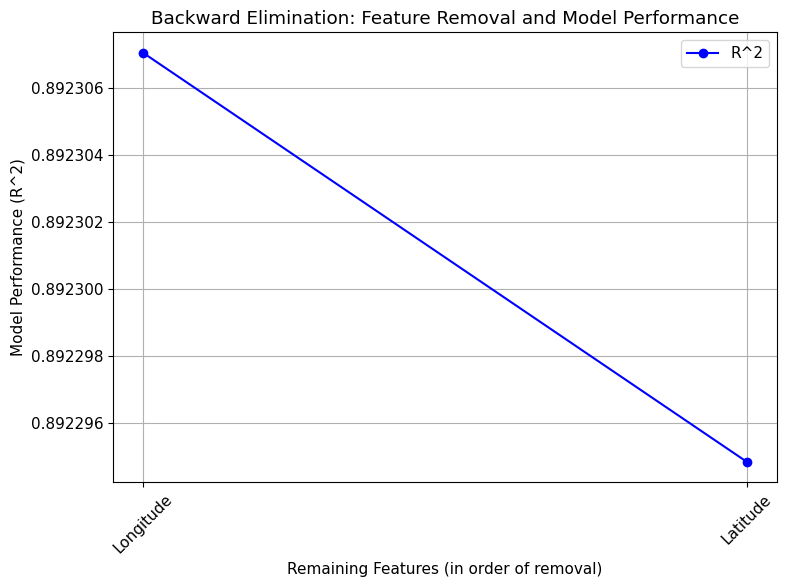

In [17]:
plt.figure(figsize=(8, 6))

x_ticks = range(len(model_performance_backward))

# 모델 성능 그래프
plt.plot(x_ticks, model_performance_backward, marker='o', linestyle='-', color='b', label='R^2')

# x축 레이블 (남아있는 변수 이름) 길이 조정
adjusted_features = selected_features_backward[::-1][:len(model_performance_backward)]
plt.xticks(x_ticks, adjusted_features, rotation=45)

plt.xlabel('Remaining Features (in order of removal)')
plt.ylabel('Model Performance (R^2)')
plt.title('Backward Elimination: Feature Removal and Model Performance')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

## **8-1-3. Bidirectional**

- **Bidirectional**: 두 방법을 동시에 적용하여 균형 잡힌 선택 수행  

In [18]:
def bidirectional_stepwise_with_visualization(X, y, significance_level_in=0.05, significance_level_out=0.05):
    selected_features = []              # 현재 선택된 변수 집합
    remaining_features = list(X.columns)  # 선택되지 않은 변수들
    model_performance = []              # 각 단계에서의 모델 성능 기록 (R²)

    while True:
        changed = False

        # -----------------------------
        # 1) Forward Selection Step
        # -----------------------------
        best_pval = float("inf")
        best_feature = None

        for feature in remaining_features:
            X_subset = sm.add_constant(X[selected_features + [feature]])
            model = sm.OLS(y, X_subset).fit()

            pval = model.pvalues[feature]

            if pval < best_pval and pval < significance_level_in:
                best_pval = pval
                best_feature = feature

        if best_feature is not None:
            selected_features.append(best_feature)
            remaining_features.remove(best_feature)
            changed = True

            # 모델 성능 저장
            X_subset = sm.add_constant(X[selected_features])
            model = sm.OLS(y, X_subset).fit()
            model_performance.append(model.rsquared)

        # -----------------------------
        # 2) Backward Elimination Step
        # -----------------------------
        if len(selected_features) > 0:
            X_subset = sm.add_constant(X[selected_features])
            model = sm.OLS(y, X_subset).fit()

            # 상수항 제외
            pvalues = model.pvalues.iloc[1:]

            worst_pval = pvalues.max()
            worst_feature = pvalues.idxmax()

            if worst_pval > significance_level_out:
                selected_features.remove(worst_feature)
                remaining_features.append(worst_feature)
                changed = True

                # 모델 성능 저장
                X_subset = sm.add_constant(X[selected_features]) if selected_features else None
                if selected_features:
                    model = sm.OLS(y, X_subset).fit()
                    model_performance.append(model.rsquared)
                else:
                    model_performance.append(None)

        # -----------------------------
        # 종료 조건
        # -----------------------------
        if not changed:
            break

    return selected_features, model_performance

# 함수 실행
selected_features_bidir, performance_bidir = bidirectional_stepwise_with_visualization(X, y)

print("Bidirectional Stepwise 이후 선택된 변수들 :", selected_features_bidir)
print("Bidirectional Stepwise 성능 변화:", performance_bidir)

Bidirectional Stepwise 이후 선택된 변수들 : ['MedInc', 'HouseAge', 'Latitude', 'Longitude', 'AveBedrms', 'AveRooms', 'AveOccup']
Bidirectional Stepwise 성능 변화: [np.float64(0.47344749180719903), np.float64(0.5091195899765226), np.float64(0.5171927045652198), np.float64(0.5940250548052656), np.float64(0.5988375576365015), np.float64(0.6050397785905599), np.float64(0.6062193051855561)]


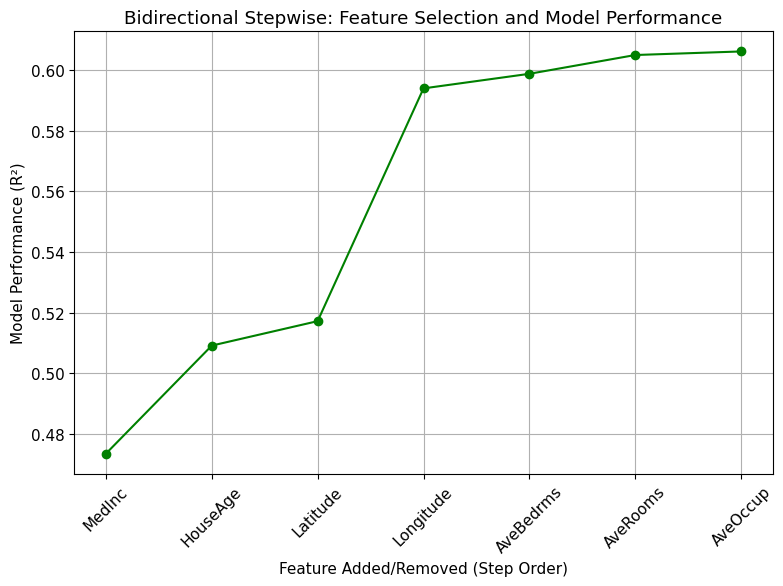

In [19]:
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(performance_bidir) + 1), performance_bidir,
         marker='o', linestyle='-', color='green')
plt.xticks(range(1, len(performance_bidir) + 1), selected_features_bidir + ([""] * (len(performance_bidir) - len(selected_features_bidir))), rotation=45)

plt.xlabel("Feature Added/Removed (Step Order)")
plt.ylabel("Model Performance (R²)")
plt.title("Bidirectional Stepwise: Feature Selection and Model Performance")
plt.grid()
plt.tight_layout()
plt.show()

## **8-1-4. AIC/BIC Stepwise Regression**

Stepwise Regression에서는 변수를 추가/제거할 때 **모델의 적합도**와 **복잡도** 사이의 균형 평가

---

#### **AIC (Akaike Information Criterion)**

$$
AIC = -2 \ln(L) + 2k
$$

- $L$: 최대 우도(likelihood)
- $k$: 모델의 파라미터 수 (변수 수 + 1)
- 값이 **낮을수록** 좋은 모델
- 예측 성능에 초점, 복잡한 모델에 관대함

---

#### **BIC (Bayesian Information Criterion)**

$$
BIC = -2 \ln(L) + k \ln(n)
$$

- $L$: 최대 우도(likelihood)
- $k$: 모델의 파라미터 수
- $n$: 샘플 수 (데이터 개수)
- 값이 **낮을수록** 좋은 모델
- 단순한 모델 선호, 과적합 방지에 효과적


In [21]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

def bidirectional_stepwise_with_visualization(X, y, criterion="aic"):
    """
    criterion 옵션:
    - "aic" : AIC 기준 stepwise
    - "bic" : BIC 기준 stepwise
    """

    selected_features = []
    remaining_features = list(X.columns)

    performance_history = []   # 선택된 기준(AIC 또는 BIC)의 변화 기록
    feature_history = []       # 변수 선택 과정 저장

    current_score = float("inf")   # AIC/BIC는 낮을수록 좋음

    while True:
        changed = False

        # -----------------------------
        # Forward Selection
        # -----------------------------
        best_feature = None
        best_score = current_score

        for feature in remaining_features:
            X_subset = sm.add_constant(X[selected_features + [feature]])
            model = sm.OLS(y, X_subset).fit()

            score = model.aic if criterion == "aic" else model.bic

            if score < best_score:
                best_score = score
                best_feature = feature

        if best_feature is not None:
            selected_features.append(best_feature)
            remaining_features.remove(best_feature)
            current_score = best_score
            changed = True

            performance_history.append(current_score)
            feature_history.append(selected_features.copy())

        # -----------------------------
        # Backward Elimination
        # -----------------------------
        if len(selected_features) > 0:
            scores = {}
            for feature in selected_features:
                tmp_list = [f for f in selected_features if f != feature]
                X_subset = sm.add_constant(X[tmp_list])
                model_tmp = sm.OLS(y, X_subset).fit()
                scores[feature] = model_tmp.aic if criterion == "aic" else model_tmp.bic

            worst_feature = min(scores, key=scores.get)
            worst_score = scores[worst_feature]

            if worst_score < current_score:
                selected_features.remove(worst_feature)
                remaining_features.append(worst_feature)
                current_score = worst_score
                changed = True

                performance_history.append(current_score)
                feature_history.append(selected_features.copy())

        if not changed:
            break

    return selected_features, performance_history, feature_history

최종 선택된 변수 : ['MedInc', 'HouseAge', 'Latitude', 'Longitude', 'AveBedrms', 'AveRooms', 'AveOccup']
성능 변화 기록 : [np.float64(51249.337663283586), np.float64(49803.430863592366), np.float64(49463.15910098319), np.float64(45887.707294155705), np.float64(45643.57513109551), np.float64(45323.97536705191), np.float64(45264.242936114046)]


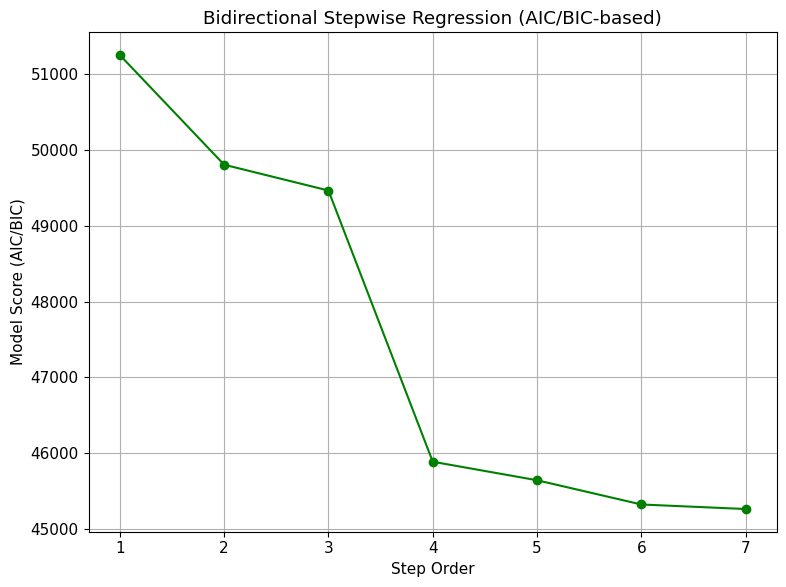

In [22]:
selected_features_bidir, score_history, history_features = bidirectional_stepwise_with_visualization(
    X, y, criterion="aic"   # "aic" 또는 "bic"
)

print("최종 선택된 변수 :", selected_features_bidir)
print("성능 변화 기록 :", score_history)

plt.figure(figsize=(8, 6))
plt.plot(range(1, len(score_history) + 1), score_history,
         marker='o', linestyle='-', color='green')

plt.xlabel("Step Order")
plt.ylabel("Model Score (AIC/BIC)")
plt.title("Bidirectional Stepwise Regression (AIC/BIC-based)")
plt.grid()
plt.tight_layout()
plt.show()


### **8-2. Quantile Regression**

\begin{equation}
Q_\tau(Y|X) = \beta_{\tau,0} + \beta_{\tau,1} x_1 + \cdots + \beta_{\tau,p} x_p
\end{equation}

- 평균이 아니라 **조건부 분위수(quantile)** 를 예측하는 회귀
- 평균(OLS)만 설명하는 대신, **분포의 여러 지점(예: 0.1, 0.5, 0.9 분위)** 을 직접 추정  
- **Pinball(Quantile) Loss** 최소화를 통해 학습  
- 장점:  
  - **비대칭 분포**나 **꼬리(heavy tail)** 특성을 반영 가능  
  - **이상치(outlier)에 강건** (특히 median regression, q=0.5)  
  - 중앙값, 하위/상위 분위 등 **다양한 조건부 경향** 분석 가능  
- 단점:
  - 느린 연산 속도  
  - 평균 기준 지표(MSE, R²)에서는 OLS보다 불리하게 보일 수 있음  
  - 분위 간 **교차(crossing)** 문제 발생 가능  

In [58]:
# 다양한 분위수에 대한 모델 학습 및 평가 지표 출력
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

quantiles_housing = [0.1, 0.25, 0.5, 0.75, 0.9]
qr_results = {}

for q in quantiles_housing:
    qr_model = QuantileRegressor(quantile=q, alpha=0.1, solver='highs')
    qr_model.fit(X_train_scaled, y_train)
    y_pred_qr = qr_model.predict(X_test_scaled)

    # 평가 지표 계산
    mae = mean_absolute_error(y_test, y_pred_qr)
    mse = mean_squared_error(y_test, y_pred_qr)
    r2 = r2_score(y_test, y_pred_qr)

    qr_results[q] = {
        'model': qr_model,
        'predictions': y_pred_qr,
        'mae': mae,
        'mse': mse,
        'r2': r2
    }

    # 결과 출력
    print(f"\n[Quantile {q} Regression 모델 평가 지표]")
    print("- 평균 절대 오차 (MAE):", round(mae, 4))
    print("- 평균 제곱 오차 (MSE):", round(mse, 4))
    print("- R-제곱 (R2) 값:", round(r2, 4))


[Quantile 0.1 Regression 모델 평가 지표]
- 평균 절대 오차 (MAE): 1.2675
- 평균 제곱 오차 (MSE): 2.8233
- R-제곱 (R2) 값: -1.1545

[Quantile 0.25 Regression 모델 평가 지표]
- 평균 절대 오차 (MAE): 0.7734
- 평균 제곱 오차 (MSE): 1.2099
- R-제곱 (R2) 값: 0.0767

[Quantile 0.5 Regression 모델 평가 지표]
- 평균 절대 오차 (MAE): 0.6286
- 평균 제곱 오차 (MSE): 0.7666
- R-제곱 (R2) 값: 0.415

[Quantile 0.75 Regression 모델 평가 지표]
- 평균 절대 오차 (MAE): 0.796
- 평균 제곱 오차 (MSE): 0.8866
- R-제곱 (R2) 값: 0.3234

[Quantile 0.9 Regression 모델 평가 지표]
- 평균 절대 오차 (MAE): 1.5616
- 평균 제곱 오차 (MSE): 2.9439
- R-제곱 (R2) 값: -1.2466


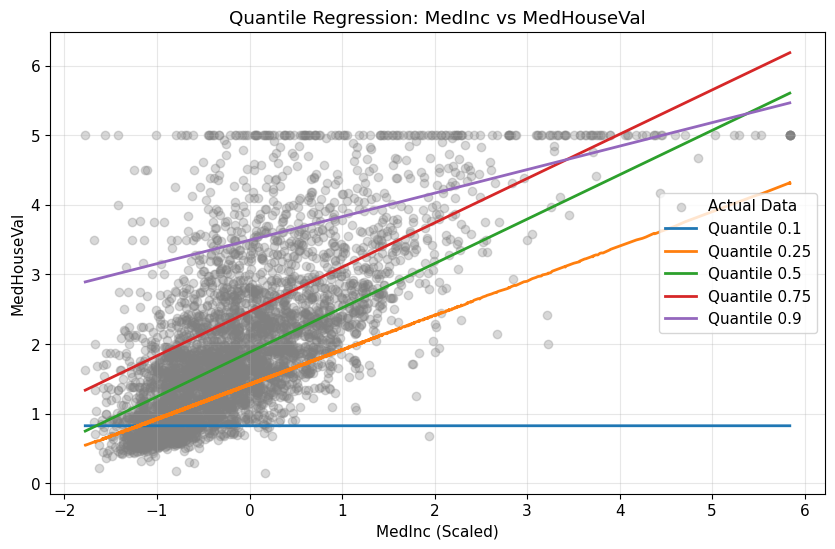

In [ ]:
# MedInc 기준 정렬
sorted_idx = np.argsort(X_test_scaled[feature_name])
x_sorted = X_test_scaled[feature_name].values[sorted_idx]
y_test_sorted = y_test.values[sorted_idx]

plt.figure(figsize=(10, 6))

# 실제 데이터 산점도
plt.scatter(x_sorted, y_test_sorted, alpha=0.3, label="Actual Data")

# 분위수별 예측 곡선 추가
for q in quantiles_housing:
    y_pred_sorted = qr_results[q]['predictions'][sorted_idx]
    plt.plot(x_sorted, y_pred_sorted, linewidth=2, label=f"Quantile {q}")

plt.title("Quantile Regression: MedInc vs MedHouseVal")
plt.xlabel("MedInc (Scaled)")
plt.ylabel("MedHouseVal")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### **8-3. Bayesian Regression**

- 회귀 계수를 **점추정**이 아닌 **확률분포**로 추정하는 모델
- **불확실성까지 예측** : 예측값뿐 아니라 표준편차/예측구간(PI) 제공
- **사전(prior)으로 수축** : 작은 표본·다중공선성에서 과적합 완화
- **ARD (Automatic Relevance Determination)** : 불필요한 변수의 계수를 자동으로 0 근처로 수축
- 장점:
    - 작은 n / 큰 p, 강한 다중공선성에서도 안정적인 추정 가능
    - 계수·예측의 불확실성을 함께 제공
- 단점:
    - 가우시안/등분산 가정에 기반하여 이상치·비대칭 분포·이분산에 취약
    - 사전(prior) 의존성으로 인한 편향 가능
    - 하이퍼파라미터·evidence 해석이 직관적이지 않음


- 모델 학습 및 예측

In [60]:
from sklearn.linear_model import BayesianRidge

# Bayesian Ridge 모델 학습
bayesian_model = BayesianRidge(compute_score=True) #각 iteration 마다 log margin liklihood 계산
bayesian_model.fit(X_train_scaled, y_train)

# 예측 (평균과 표준편차 반환)
y_pred_bayes, y_std_bayes = bayesian_model.predict(X_test_scaled, return_std=True) #예측 불확실성을 나타내는 표준편차를 추가로 반환

- 모델 평가

In [61]:
mae_bayes = mean_absolute_error(y_test, y_pred_bayes)
mse_bayes = mean_squared_error(y_test, y_pred_bayes)
r2_bayes = r2_score(y_test, y_pred_bayes)

print("\n[Bayesian Ridge Regression 모델 평가 지표]")
print("\n- 평균 절대 오차 (MAE):", round(mae_bayes, 4))
print("- 평균 제곱 오차 (MSE):", round(mse_bayes, 4))
print("- R-제곱 (R2) 값:", round(r2_bayes, 4))


[Bayesian Ridge Regression 모델 평가 지표]

- 평균 절대 오차 (MAE): 0.5332
- 평균 제곱 오차 (MSE): 0.5558
- R-제곱 (R2) 값: 0.5758


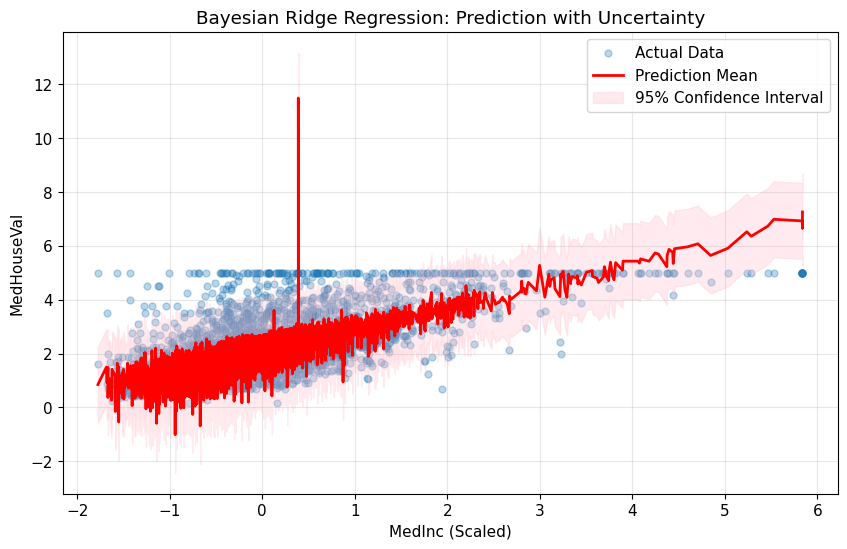

In [64]:
# -------- Bayesian Ridge Regression Visualization --------

import matplotlib.pyplot as plt
import numpy as np

feature_name = "MedInc"

# Med렬 기준 정렬
sorted_idx = np.argsort(X_test_scaled[feature_name])
x_sorted = X_test_scaled[feature_name].values[sorted_idx]
y_test_sorted = y_test.values[sorted_idx]
y_pred_sorted = y_pred_bayes[sorted_idx]
y_std_sorted = y_std_bayes.iloc[sorted_idx]   # 위치 기반 인덱싱으로 수정

# 95% 신뢰구간 계산 (mean ± 1.96 * std)
upper = y_pred_sorted + 1.96 * y_std_sorted
lower = y_pred_sorted - 1.96 * y_std_sorted

plt.figure(figsize=(10, 6))

# 실제 데이터
plt.scatter(x_sorted, y_test_sorted, s=25, alpha=0.3, label="Actual Data")

# 예측 평균
plt.plot(x_sorted, y_pred_sorted, color="red", linewidth=2, label="Prediction Mean")

# 신뢰구간 영역 표시
plt.fill_between(x_sorted, lower, upper, color="pink", alpha=0.3, label="95% Confidence Interval")

plt.title("Bayesian Ridge Regression: Prediction with Uncertainty")
plt.xlabel("MedInc (Scaled)")
plt.ylabel("MedHouseVal")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## **8-4. 일반화 선형 모델 (Generalized Linear Model, GLM)**
 
- 종속변수가 정규분포가 아닐 때 사용하는 일반화된 회귀 프레임워크
- 다양한 분포(이항, 포아송 등) 지원  
- 링크 함수(link function)를 통해 분포와 선형식 연결

 - **주요 GLM 유형**:
   | 분포 | 링크 함수 | 사용 사례 |
   |------|----------|----------|
   | 정규(Gaussian) | Identity | 일반 회귀 |
   | 이항(Binomial) | Logit | 분류 문제 |
   | 포아송(Poisson) | Log | 카운트 데이터 |
   | 감마(Gamma) | Log | 양수 연속 변수 |
 
 - **장점**:
   - 다양한 종속변수 분포에 대응 가능
   - 비선형 관계를 선형 프레임워크에서 모델링

- **단점**
   - 분포와 링크 함수 선택이 어려워 모델링이 복잡할 수 있음
   - 결과 해석이 직관적이지 않음

 ### **7-4-1. GLM with Gaussian Family (Identity Link)**

- Gaussian GLM 모델

In [35]:
glm_gaussian = sm.GLM(y_train, X_train_const, family=sm.families.Gaussian(link=sm.families.links.Identity()))
glm_gaussian_fit = glm_gaussian.fit()

print("\n[GLM Gaussian Model Summary]")
print(glm_gaussian_fit.summary())

# 예측 및 평가
y_pred_gaussian = glm_gaussian_fit.predict(X_test_const)

mae_gaussian = mean_absolute_error(y_test, y_pred_gaussian)
mse_gaussian = mean_squared_error(y_test, y_pred_gaussian)
r2_gaussian = r2_score(y_test, y_pred_gaussian)

print("\n[GLM (Gaussian, Identity Link) 모델 평가 지표]")
print(f"- MAE: {mae_gaussian:.4f}")
print(f"- MSE: {mse_gaussian:.4f}")
print(f"- R2: {r2_gaussian:.4f}")


[GLM Gaussian Model Summary]
                 Generalized Linear Model Regression Results                  
Dep. Variable:            MedHouseVal   No. Observations:                16512
Model:                            GLM   Df Residuals:                    16503
Model Family:                Gaussian   Df Model:                            8
Link Function:               Identity   Scale:                         0.51822
Method:                          IRLS   Log-Likelihood:                -17998.
Date:                Tue, 02 Dec 2025   Deviance:                       8552.1
Time:                        11:16:48   Pearson chi2:                 8.55e+03
No. Iterations:                     3   Pseudo R-squ. (CS):             0.7941
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.0719 

- Binomial GLM(Logit Link) 모델

In [37]:
glm_binomial = sm.GLM(y_train, X_train_const, family=sm.families.Binomial(link=sm.families.links.Logit()))
glm_binomial_fit = glm_binomial.fit()

print("\n[GLM Binomial Model Summary]")
print(glm_binomial_fit.summary())

# 예측
y_pred_prob = glm_binomial_fit.predict(X_test_const)
y_pred_binomial = (y_pred_prob >= 0.5).astype(int)

# 평가
mae_binomial = mean_absolute_error(y_test, y_pred_binomial)
mse_binomial = mean_squared_error(y_test, y_pred_binomial)
r2_binomial = r2_score(y_test, y_pred_binomial)

print("\n[GLM (Binomial, Logit Link) 모델 평가 지표]")
print(f"- MAE: {mae_binomial:.4f}")
print(f"- MSE: {mse_binomial:.4f}")
print(f"- R2: {r2_binomial:.4f}")


[GLM Binomial Model Summary]
                 Generalized Linear Model Regression Results                  
Dep. Variable:            MedHouseVal   No. Observations:                16512
Model:                            GLM   Df Residuals:                    16503
Model Family:                Binomial   Df Model:                            8
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                   -inf
Date:                Tue, 02 Dec 2025   Deviance:                   1.4945e+06
Time:                        11:17:23   Pearson chi2:                 1.88e+20
No. Iterations:                    14   Pseudo R-squ. (CS):                nan
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       6.087e+16 

- Poisson GLM 모델

In [38]:
glm_poisson = sm.GLM(y_train, X_train_const, family=sm.families.Poisson(link=sm.families.links.Log()))
glm_poisson_fit = glm_poisson.fit()

print("\n[GLM Poisson Model Summary]")
print(glm_poisson_fit.summary())

# 예측 및 평가
y_pred_poisson = glm_poisson_fit.predict(X_test_const)

mae_poisson = mean_absolute_error(y_test, y_pred_poisson)
mse_poisson = mean_squared_error(y_test, y_pred_poisson)
r2_poisson = r2_score(y_test, y_pred_poisson)

print("\n[GLM (Poisson, Log Link) 모델 평가 지표]")
print(f"- MAE: {mae_poisson:.4f}")
print(f"- MSE: {mse_poisson:.4f}")
print(f"- R2: {r2_poisson:.4f}")


[GLM Poisson Model Summary]
                 Generalized Linear Model Regression Results                  
Dep. Variable:            MedHouseVal   No. Observations:                16512
Model:                            GLM   Df Residuals:                    16503
Model Family:                 Poisson   Df Model:                            8
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -22819.
Date:                Tue, 02 Dec 2025   Deviance:                       4040.3
Time:                        11:17:33   Pearson chi2:                 4.30e+03
No. Iterations:                     6   Pseudo R-squ. (CS):             0.3036
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6446  

- Gamma GLM(Log Link) 모델

In [39]:
glm_gamma = sm.GLM(y_train, X_train_const, family=sm.families.Gamma(link=sm.families.links.Log()))
glm_gamma_fit = glm_gamma.fit()

print("\n[GLM Gamma Model Summary]")
print(glm_gamma_fit.summary())

# 예측 및 평가
y_pred_glm_gamma = glm_gamma_fit.predict(X_test_const)

mae_glm_gamma = mean_absolute_error(y_test, y_pred_glm_gamma)
mse_glm_gamma = mean_squared_error(y_test, y_pred_glm_gamma)
r2_glm_gamma = r2_score(y_test, y_pred_glm_gamma)

print("\n[GLM (Gamma, Log Link) 모델 평가 지표]")
print(f"- MAE: {mae_glm_gamma:.4f}")
print(f"- MSE: {mse_glm_gamma:.4f}")
print(f"- R2: {r2_glm_gamma:.4f}")


[GLM Gamma Model Summary]
                 Generalized Linear Model Regression Results                  
Dep. Variable:            MedHouseVal   No. Observations:                16512
Model:                            GLM   Df Residuals:                    16503
Model Family:                   Gamma   Df Model:                            8
Link Function:                    Log   Scale:                         0.13832
Method:                          IRLS   Log-Likelihood:                -15900.
Date:                Tue, 02 Dec 2025   Deviance:                       2046.5
Time:                        11:18:09   Pearson chi2:                 2.28e+03
No. Iterations:                    25   Pseudo R-squ. (CS):             0.7392
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6355    

### **8-5. Spline Regression**

- 하나의 직선이 아닌, **구간별(piecewise)** 다항함수로 비선형 관계 모델링
- 전체 구간에서 하나의 다항식(예: 다항 회귀)을 쓰는 대신, 특정 지점(**knots**)을 기준으로 구간을 나누어 각 구간마다 다항식을 적합
- 구간이 바뀌더라도 함수값과 기울기(미분값)가 매끄럽게 이어지도록 **연속성(continuity)** 조건을 부여

- 장점:  
  - 비선형 패턴을 효과적으로 설명할 수 있음
  - 고차 다항식 회귀보다 안정적이고 과적합 위험이 적음
  - 국소적으로 유연하여 다양한 데이터 형태를 잘 포착


- 단점:
  - Knot의 위치와 개수를 임의로 정해야 하는 경우 다수 → 모델 선택 어려움
  - 구간이 많아질수록 모델이 복잡해지고 해석력 저해
  - Knot 위치를 잘못 선택하면 성능이 크게 저하

In [ ]:
from patsy import dmatrix

# 스플라인 기저
X_train_spline = dmatrix(
    "bs(x, df=4, degree=3, include_intercept=False)",
    {"x": X_train_scaled['MedInc']},
    return_type='dataframe'
)

spline_model = LinearRegression()
spline_model.fit(X_train_spline, y_train)

X_test_spline = dmatrix(
    "bs(x, df=4, degree=3, include_intercept=False)",
    {"x": X_test_scaled['MedInc']},
    return_type='dataframe'
)

y_pred_spline = spline_model.predict(X_test_spline)

In [42]:
# 모델 평가
mae_spline = mean_absolute_error(y_test, y_pred_spline)
mse_spline = mean_squared_error(y_test, y_pred_spline)
r2_spline = r2_score(y_test, y_pred_spline)

print("\n[Spline Regression (on MedInc) 모델 평가 지표]")
print("\n- 평균 절대 오차 (MAE):", round(mae_spline, 4))
print("- 평균 제곱 오차 (MSE):", round(mse_spline, 4))
print("- R-제곱 (R2) 값:", round(r2_spline, 4))


[Spline Regression (on MedInc) 모델 평가 지표]

- 평균 절대 오차 (MAE): 0.623
- 평균 제곱 오차 (MSE): 0.6972
- R-제곱 (R2) 값: 0.4679


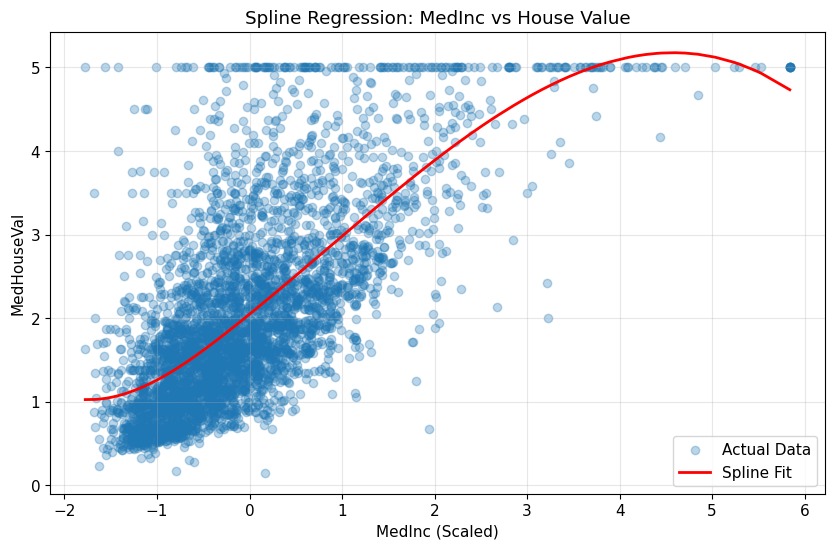

In [43]:
# Spline 적합 결과 시각화
# MedInc 값을 정렬하여 시각화
sort_idx = X_test_scaled['MedInc'].argsort()
X_plot = X_test_scaled['MedInc'].iloc[sort_idx]
y_plot = y_pred_spline[sort_idx]

plt.figure(figsize=(10, 6))
plt.scatter(X_test_scaled['MedInc'], y_test, alpha=0.3, label='Actual Data')
plt.plot(X_plot, y_plot, 'r-', linewidth=2, label='Spline Fit')
plt.xlabel('MedInc (Scaled)')
plt.ylabel('MedHouseVal')
plt.title('Spline Regression: MedInc vs House Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### **8-6. Locally Weighted Regression**

- 전역적인 하나의 모델을 학습하지 않고, **각 예측 지점마다 주변 데이터에 가중치를 부여**하여 국소적인 회귀를 수행

- 장점:
  - 함수 형태를 사전에 가정하지 않아 **복잡한 비선형 패턴**도 자연스럽게 포착
  - 국소적 변화에 민감하게 반응
  - 탐색적 데이터 분석(EDA) 및 시각화에 유용

- 단점:
  - **계산 비용이 높음** (예측할 때마다 회귀를 새로 수행)
  - 전역 계수가 없어 **해석이 어려움**
  - 고차원 데이터에서 성능 저하 (**차원의 저주**)
  - 새로운 데이터에 대한 예측 속도가 느림

- LWR (Locally Weighted Regression)
    - 국소 영역에서 회귀하여 예측 수행

In [54]:
knn_lwr_model = KNeighborsRegressor(n_neighbors=10, weights="distance")
knn_lwr_model.fit(X_train_scaled, y_train)

y_pred_knn_lwr = knn_lwr_model.predict(X_test_scaled)

# 평가 지표 계산
mae_knn = mean_absolute_error(y_test, y_pred_knn_lwr)
mse_knn = mean_squared_error(y_test, y_pred_knn_lwr)
r2_knn = r2_score(y_test, y_pred_knn_lwr)

print("\n[Multivariate Locally Weighted Regression (KNN) Evaluation]")
print("- MAE:", round(mae_knn, 4))
print("- MSE:", round(mse_knn, 4))
print("- R2:", round(r2_knn, 4))


[Multivariate Locally Weighted Regression (KNN) Evaluation]
- MAE: 0.4368
- MSE: 0.4163
- R2: 0.6823


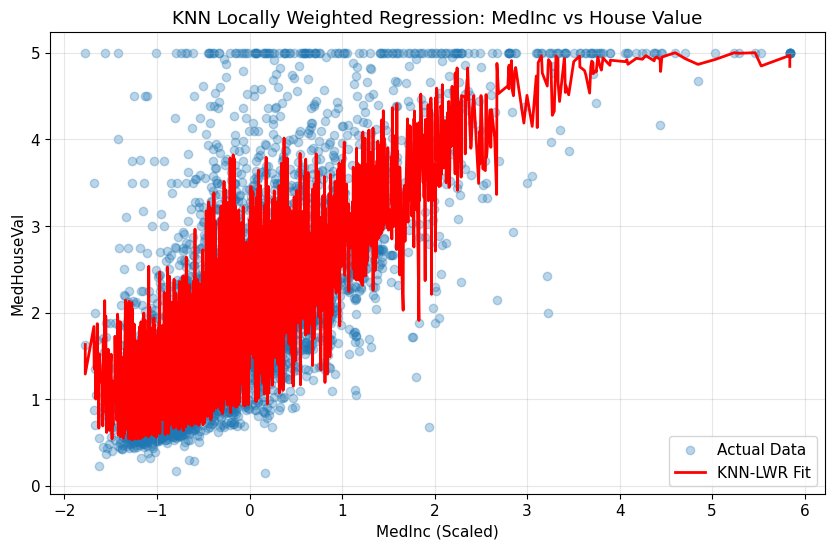

In [53]:
import matplotlib.pyplot as plt
import numpy as np

# 특정 feature 설정 (예: MedInc)
feature_name = "MedInc"

# feature 기준 정렬
sorted_idx = np.argsort(X_test_scaled[feature_name])
x_sorted = X_test_scaled[feature_name].values[sorted_idx]
y_test_sorted = y_test.values[sorted_idx]
y_pred_sorted = y_pred_knn_lwr[sorted_idx]

plt.figure(figsize=(10, 6))

# 실제 데이터 (파란색)
plt.scatter(x_sorted, y_test_sorted, alpha=0.3, label="Actual Data")

# 예측 곡선 (빨간색)
plt.plot(x_sorted, y_pred_sorted, color="red", linewidth=2, label="KNN-LWR Fit")

plt.title("KNN Locally Weighted Regression: MedInc vs House Value")
plt.xlabel("MedInc (Scaled)")
plt.ylabel("MedHouseVal")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


- LOWESS(Locally Weighted Scatterplot Smoothing)
    - 데이터의 패턴을 시각적으로 부드럽게 묘사  
    -  시각화 목적

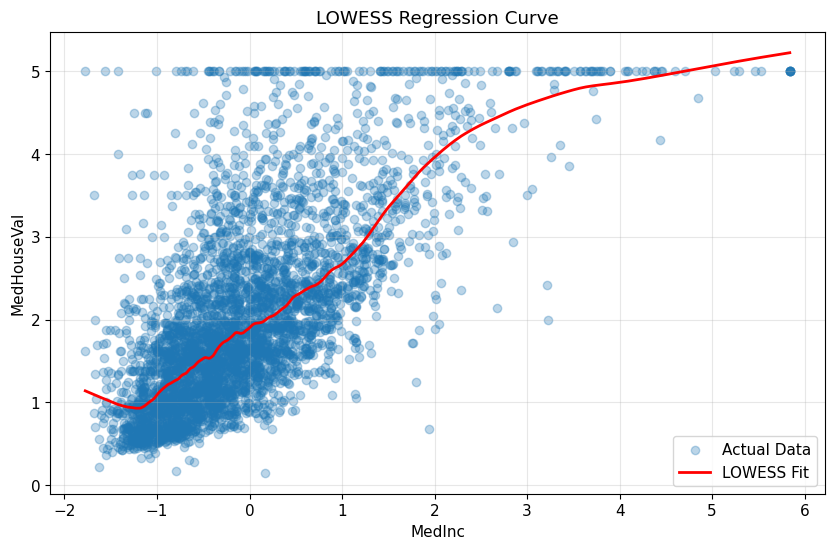

In [47]:
from statsmodels.nonparametric.smoothers_lowess import lowess

lowess_result = lowess(y_test, X_test_scaled[feature_name], frac=0.1)

plt.figure(figsize=(10,6))
plt.scatter(X_test_scaled[feature_name], y_test, alpha=0.3, label="Actual Data")
plt.plot(lowess_result[:,0], lowess_result[:,1], color='red', linewidth=2, label='LOWESS Fit')
plt.xlabel(feature_name)
plt.ylabel("MedHouseVal")
plt.title("LOWESS Regression Curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()